# ANP-SBI Pipeline v2 — Multi-redshift, Multi-channel Inference

Upgrades over v1:
- Multi-z emulator support (z = 0, 0.5, 1.0)
- Mass × redshift binning in summary statistics
- **Configurable observable channels**: kT, ne, P, Z, K (entropy), y (Compton-y)
- **Cross-channel features**: T_core_ratio, K_slope, ne_slope
- **Survey selection functions** for forward-model correction
- **SBC validation** and **multi-dataset ablation**
- Unified observational data loading via `anp_emulator.observations`
- Modular pipeline class from `anp_sbi_pipeline_v2`

In [1]:
import sys
from pathlib import Path

# Allow imports from the repo root
sys.path.insert(0, str(Path('..').resolve()))

import logging
import numpy as np
import torch

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)s %(message)s')
logger = logging.getLogger(__name__)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}, torch {torch.__version__}')

Device: cuda, torch 2.5.1+cu124


## Configuration

Choose between single-z (existing best model) or multi-z (once trained).

In [2]:
# ── Paths ──────────────────────────────────────────────────────────
# Single-z checkpoint (existing best model)
ANP_CKPT_SINGLEZ = str(Path('..') / 'anp_training_runs' /
                       'anp_all_profiles_20260325_175639' / 'best_model.pt')

# Multi-z checkpoint (update once multiz training completes)
ANP_CKPT_MULTIZ = str(Path('..') / 'anp_training_runs' /
                       'anp_all_profiles_20260406_211444' / 'best_model.pt')  # e.g. '../anp_training_runs/anp_all_profiles_multiz_.../best_model.pt'

# Select which to use
USE_MULTIZ = True  # Set True once multi-z model is trained
ANP_CKPT = ANP_CKPT_MULTIZ if USE_MULTIZ else ANP_CKPT_SINGLEZ

# Data
FIT_DATA_DIR = Path('/mnt/home/mlee1/fit_data/processed_data')
OBS_NPZ = str(FIT_DATA_DIR / 'obs_expanded.npz')
TRAIN_NPZ = str(FIT_DATA_DIR / 'train_data_joint.npz')

# ── Pipeline settings ──────────────────────────────────────────────
QUICK_TEST = False   # Fast run with N_SIMS=10k for debugging
FIX_COSMO = True   # True = fix cosmology, infer only astro params

N_SIMS = 10_000 if QUICK_TEST else 200_000
N_POSTERIOR = 100 if QUICK_TEST else 50_000

print(f'Checkpoint: {ANP_CKPT}')
print(f'Multi-z: {USE_MULTIZ}')
print(f'Quick test: {QUICK_TEST}, N_sims={N_SIMS:,}')

Checkpoint: ../anp_training_runs/anp_all_profiles_20260406_211444/best_model.pt
Multi-z: True
Quick test: False, N_sims=200,000


## Initialize Pipeline

In [ ]:
from anp_sbi_pipeline_v2 import SBIPipeline, SBIConfig

# Configure mass and redshift bins
if USE_MULTIZ:
    z_bin_edges = (0.0, 0.15, 0.5, 1.0)   # 3 z-bins
else:
    # Single-z: include ALL clusters regardless of z (matches v1 behavior)
    z_bin_edges = (0.0, 1.0)

# ── Summary channel selection ──────────────────────────────────────
# Available: 'kT', 'ne', 'P' (pressure), 'Z' (metallicity),
#            'K' (entropy), 'y' (Compton-y proxy)
# Cross-features: 'T_core_ratio', 'K_slope', 'ne_slope'
# NOTE: Z requires emu_fields to include 'metallicity'
SUMMARY_CHANNELS = ('kT', 'ne', 'P')   # baseline: same as v1
# SUMMARY_CHANNELS = ('kT', 'ne', 'P', 'K')  # + entropy (derived)
# SUMMARY_CHANNELS = ('kT', 'ne', 'P', 'Z', 'K')  # + metallicity + entropy (needs emu_fields update)

CROSS_FEATURES = ()          # baseline: no cross-features
# CROSS_FEATURES = ('T_core_ratio', 'K_slope')  # cool-core + entropy slope

# If using Z channel, add metallicity to emu_fields
EMU_FIELDS = ('temperature', 'gas_density')
if 'Z' in SUMMARY_CHANNELS:
    EMU_FIELDS = ('temperature', 'gas_density', 'metallicity')

config = SBIConfig(
    emu_checkpoint=ANP_CKPT,
    device=DEVICE,
    obs_npz=OBS_NPZ,
    mass_bin_edges=(13.2, 13.6, 14.0, 14.5, 14.9),
    z_bin_edges=z_bin_edges,
    emu_fields=EMU_FIELDS,
    summary_channels=SUMMARY_CHANNELS,
    cross_features=CROSS_FEATURES,
    n_sims=N_SIMS,
    n_posterior=N_POSTERIOR,
    fix_cosmo=FIX_COSMO,
    n_anp_samples=10,
    max_gpu_rows=16384,
    sample_with='mcmc',             # MCMC avoids low-acceptance rejection sampling
    mcmc_method='slice_np_vectorized',
    seed=12345,
)

pipe = SBIPipeline(config)
print(f'Config: {config.n_mass_bins} mass × {config.n_z_bins} z bins')
print(f'Channels: {config.summary_channels}, Cross-features: {config.cross_features}')
print(f'Emu fields: {config.emu_fields}')

Config: 4 mass bins × 3 z bins


## Load Emulator & Data

In [4]:
pipe.load_emulator()
pipe.load_observations()
pipe.load_training_data(TRAIN_NPZ)

2026-04-07 02:11:13,616 INFO Loaded emulator: best_model.pt (channels: ['gas_density', 'temperature', 'pressure', 'metallicity'])
2026-04-07 02:11:13,867 INFO ACCEPT+X-COP: loaded 129 clusters (mass [13.2, 15.0])
2026-04-07 02:11:13,868 INFO Total observations: 129 clusters, z=[0.003, 0.545], logM=[13.2, 14.9]
2026-04-07 02:11:13,911 INFO Training data: 59843 runs, 35 params, R500 relation fit from 17521 halos


## Setup Prior & Summary Layout

In [5]:
pipe.setup_prior()

# build_layout() defaults to CAMELS training grid (skip inner 4, matching v1)
pipe.build_layout()

radial_bins = pipe._radial_bins
print(f'\nRadial grid: {len(radial_bins)} bins, [{radial_bins[0]:.1f}, {radial_bins[-1]:.1f}] kpc')
print(f'Summary dimension: {pipe.layout["n_summary"]}')
print(f'x_obs shape: {pipe.x_obs.shape}')
print(f'x_obs non-zero: {(pipe.x_obs != 0).sum()}/{len(pipe.x_obs)}')

2026-04-07 02:11:15,598 INFO Note: NumExpr detected 64 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-04-07 02:11:15,599 INFO NumExpr defaulting to 16 threads.
2026-04-07 02:11:19.393233: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 02:11:19.914300: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-07 02:11:34,742 INFO Prior: 30 free params (19 log-uniform, 11 linear)
2026-04-07 02:11:34,761 INFO Summary: 204 dims across 12 (mass×z) bins
2026-04-07 02:11:34,761 INFO   M[13.2-13.6]


Radial grid: 21 bins, [25.4, 1600.1] kpc
Summary dimension: 204
x_obs shape: (204,)
x_obs non-zero: 119/204


## Generate Forward Model Simulations

In [6]:
pipe.generate_simulations()

2026-04-07 02:12:25,095 INFO   Bin 0 (M[13.2-13.6] z[0.00-0.15]): 7 halos
2026-04-07 02:12:25,098 INFO   Bin 1 (M[13.2-13.6] z[0.15-0.50]): 0 halos, skip
2026-04-07 02:12:25,101 INFO   Bin 2 (M[13.2-13.6] z[0.50-1.00]): 0 halos, skip
2026-04-07 02:13:00,723 INFO   Bin 3 (M[13.6-14.0] z[0.00-0.15]): 5 halos
2026-04-07 02:13:00,726 INFO   Bin 4 (M[13.6-14.0] z[0.15-0.50]): 0 halos, skip
2026-04-07 02:13:00,729 INFO   Bin 5 (M[13.6-14.0] z[0.50-1.00]): 0 halos, skip
2026-04-07 02:17:18,435 INFO   Bin 6 (M[14.0-14.5] z[0.00-0.15]): 36 halos
2026-04-07 02:17:39,679 INFO   Bin 7 (M[14.0-14.5] z[0.15-0.50]): 3 halos
2026-04-07 02:17:39,682 INFO   Bin 8 (M[14.0-14.5] z[0.50-1.00]): 0 halos, skip
2026-04-07 02:24:15,385 INFO   Bin 9 (M[14.5-14.9] z[0.00-0.15]): 56 halos
2026-04-07 02:26:45,039 INFO   Bin 10 (M[14.5-14.9] z[0.15-0.50]): 21 halos
2026-04-07 02:26:52,151 INFO   Bin 11 (M[14.5-14.9] z[0.50-1.00]): 1 halos
2026-04-07 02:26:52,154 INFO Generated 200000 simulations in 917.1s


## Coverage Check

2026-04-07 02:26:52,397 INFO Coverage: 24/119 non-zero dims in range (20.2%)


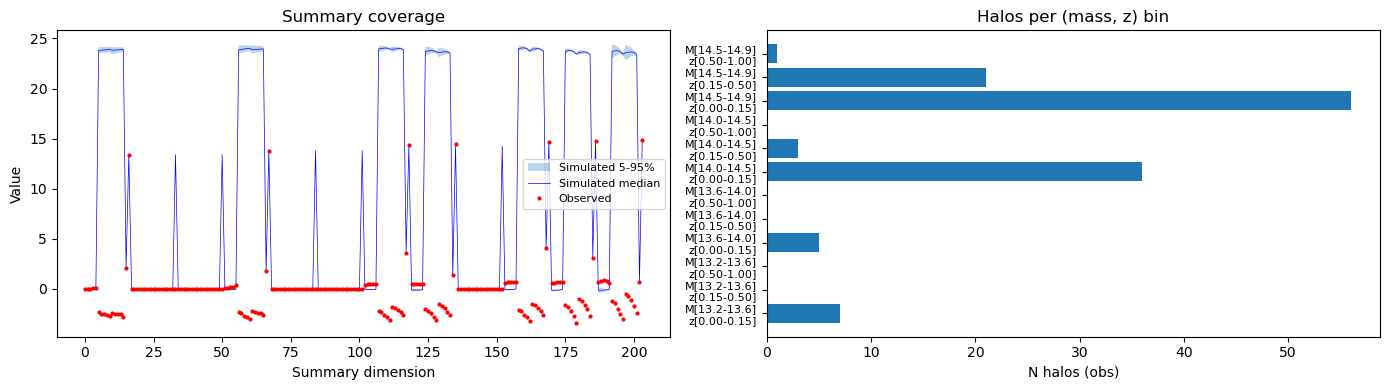

In [7]:
in_range = pipe.check_coverage()

# Visualize coverage
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: sim vs obs summary comparison
ax = axes[0]
sim_med = np.median(pipe.x_all, axis=0)
sim_lo = np.percentile(pipe.x_all, 5, axis=0)
sim_hi = np.percentile(pipe.x_all, 95, axis=0)
idx = np.arange(len(pipe.x_obs))
ax.fill_between(idx, sim_lo, sim_hi, alpha=0.3, label='Simulated 5-95%')
ax.plot(idx, sim_med, 'b-', lw=0.5, label='Simulated median')
ax.plot(idx, pipe.x_obs, 'r.', ms=4, label='Observed')
ax.set_xlabel('Summary dimension')
ax.set_ylabel('Value')
ax.legend(fontsize=8)
ax.set_title('Summary coverage')

# Right: per-bin halo counts
ax = axes[1]
labels = [f"M[{b['mass_lo']:.1f}-{b['mass_hi']:.1f}]\nz[{b['z_lo']:.2f}-{b['z_hi']:.2f}]"
          for b in pipe.layout['bins']]
counts = [b['n_halos'] for b in pipe.layout['bins']]
ax.barh(range(len(counts)), counts)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('N halos (obs)')
ax.set_title('Halos per (mass, z) bin')

plt.tight_layout()
plt.show()

## Train NPE

In [8]:
pipe.train_npe()

2026-04-07 02:27:01,645 WARNING Using NumPy C-API based implementation for BLAS functions.
2026-04-07 02:27:02,685 INFO Dropping 92 constant summary dims (of 204)


 Training neural network. Epochs trained: 200

/mnt/home/mlee1/venvs/torch3/lib/python3.10/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)
2026-04-07 02:54:51,764 INFO NPE trained successfully (sample_with=mcmc)


 Training neural network. Epochs trained: 201
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 201
        Best validation performance: 16.7395
        -------------------------
        


## Sample Posterior & Save Results

In [17]:
# Quick test: small sample via direct rejection (already-trained NPE)
import importlib, anp_sbi_pipeline_v2
importlib.reload(anp_sbi_pipeline_v2)

from sbi.inference import SNPE

# Rebuild posterior as direct (rejection) — fast for small N
inference_tmp = SNPE(prior=pipe.sbi_prior)
pipe.posterior = inference_tmp.build_posterior(
    pipe.density_estimator,
    sample_with='direct',
)

# Patch the class method from reloaded module
pipe.sample_posterior = anp_sbi_pipeline_v2.SBIPipeline.sample_posterior.__get__(pipe)
pipe.save_results = anp_sbi_pipeline_v2.SBIPipeline.save_results.__get__(pipe)

# Override n_posterior for quick test
pipe.cfg.n_posterior = 10000

samples = pipe.sample_posterior()

tag = 'v2_multiz' if USE_MULTIZ else 'v2_singlez'
pipe.save_results(results_dir='../sbi_results', tag=tag)

print(f'Posterior samples shape: {samples.shape}')
print(f'Saved to sbi_results/anp_npe_{tag}_*.{{npz,json}}')

  0%|          | 0/10000 [00:00<?, ?it/s]

2026-04-07 03:01:32,582 WARNING Only 0.260% proposal samples are
                    accepted. It may take a long time to collect the remaining
                    9974 samples. Consider interrupting (Ctrl-C) and switching to
                    `build_posterior(..., sample_with='mcmc')`.
2026-04-07 03:03:07,070 INFO Posterior: 10000 samples drawn
2026-04-07 03:03:07,214 INFO Results saved to ../sbi_results


Posterior samples shape: (10000, 35)
Saved to sbi_results/anp_npe_v2_multiz_*.{npz,json}


## Posterior Analysis

In [18]:
import json

# Compute constraint ratios in internal space for log-uniform params
ratios = {}
for i, pn in enumerate(pipe.param_names):
    if pn in pipe.selected_param_names:
        si = list(pipe.selected_param_names).index(pn)
        if pipe.is_log_param[si]:
            s = pipe.samples_internal[:, si]
            pw = pipe.prior_hi[si] - pipe.prior_lo[si]
            ratios[pn] = (np.percentile(s, 84) - np.percentile(s, 16)) / (pw + 1e-30)
        else:
            s = pipe.samples[:, i]
            pw = pipe.all_params[:, i].max() - pipe.all_params[:, i].min()
            ratios[pn] = (np.percentile(s, 84) - np.percentile(s, 16)) / (pw + 1e-30)

sorted_params = sorted(ratios.items(), key=lambda x: x[1])

print('Most constrained parameters (posterior/prior width ratio, log-space for log-uniform):')
print(f'{"Parameter":>40s}  ratio  space')
print('-' * 65)
for pn, r in sorted_params[:15]:
    si = list(pipe.selected_param_names).index(pn) if pn in pipe.selected_param_names else -1
    sp = 'log' if si >= 0 and pipe.is_log_param[si] else 'lin'
    print(f'{pn:>40s}  {r:.3f}  ({sp})')

Most constrained parameters (posterior/prior width ratio, log-space for log-uniform):
                               Parameter  ratio  space
-----------------------------------------------------------------
                     RadioFeedbackFactor  0.049  (log)
                                IMFslope  0.066  (lin)
                   VariableWindVelFactor  0.153  (log)
                   WindFreeTravelDensFac  0.262  (log)
                    QuasarThresholdPower  0.265  (lin)
       RadioFeedbackReiorientationFactor  0.272  (log)
                VariableWindSpecMomentum  0.289  (lin)
               WindEnergyReductionFactor  0.328  (log)
                     WindEnergyIn1e51erg  0.335  (log)
          WindEnergyReductionMetallicity  0.355  (log)
                 BlackHoleFeedbackFactor  0.359  (log)
                       SeedBlackHoleMass  0.405  (log)
                       SNII_MinMass_Msun  0.445  (lin)
                     ThermalWindFraction  0.451  (log)
                BlackHo

All 30 astrophysical parameters (sorted by constraining power):
  RadioFeedbackFactor                : median=0.555, 68%=[0.5208, 0.5791], w/prior=0.05 ✓
  IMFslope                           : median=-1.951, 68%=[-1.985, -1.919], w/prior=0.07 ✓
  VariableWindVelFactor              : median=0.7848, 68%=[0.7275, 0.8197], w/prior=0.15 ✓
  WindFreeTravelDensFac              : median=-0.8993, 68%=[-1.111, -0.587], w/prior=0.26 ✓
  QuasarThresholdPower               : median=1.986, 68%=[1.45, 2.509], w/prior=0.26 ✓
  RadioFeedbackReiorientationFactor  : median=1.121, 68%=[1.052, 1.216], w/prior=0.27 ✓
  VariableWindSpecMomentum           : median=3300, 68%=[2620, 3774], w/prior=0.29 ✓
  WindEnergyReductionFactor          : median=-0.2281, 68%=[-0.467, -0.07287], w/prior=0.33 ✓
  WindEnergyIn1e51erg                : median=0.9751, 68%=[0.7084, 1.112], w/prior=0.34 ✓
  WindEnergyReductionMetallicity     : median=-2.334, 68%=[-2.594, -2.168], w/prior=0.35 ✓
  BlackHoleFeedbackFactor            

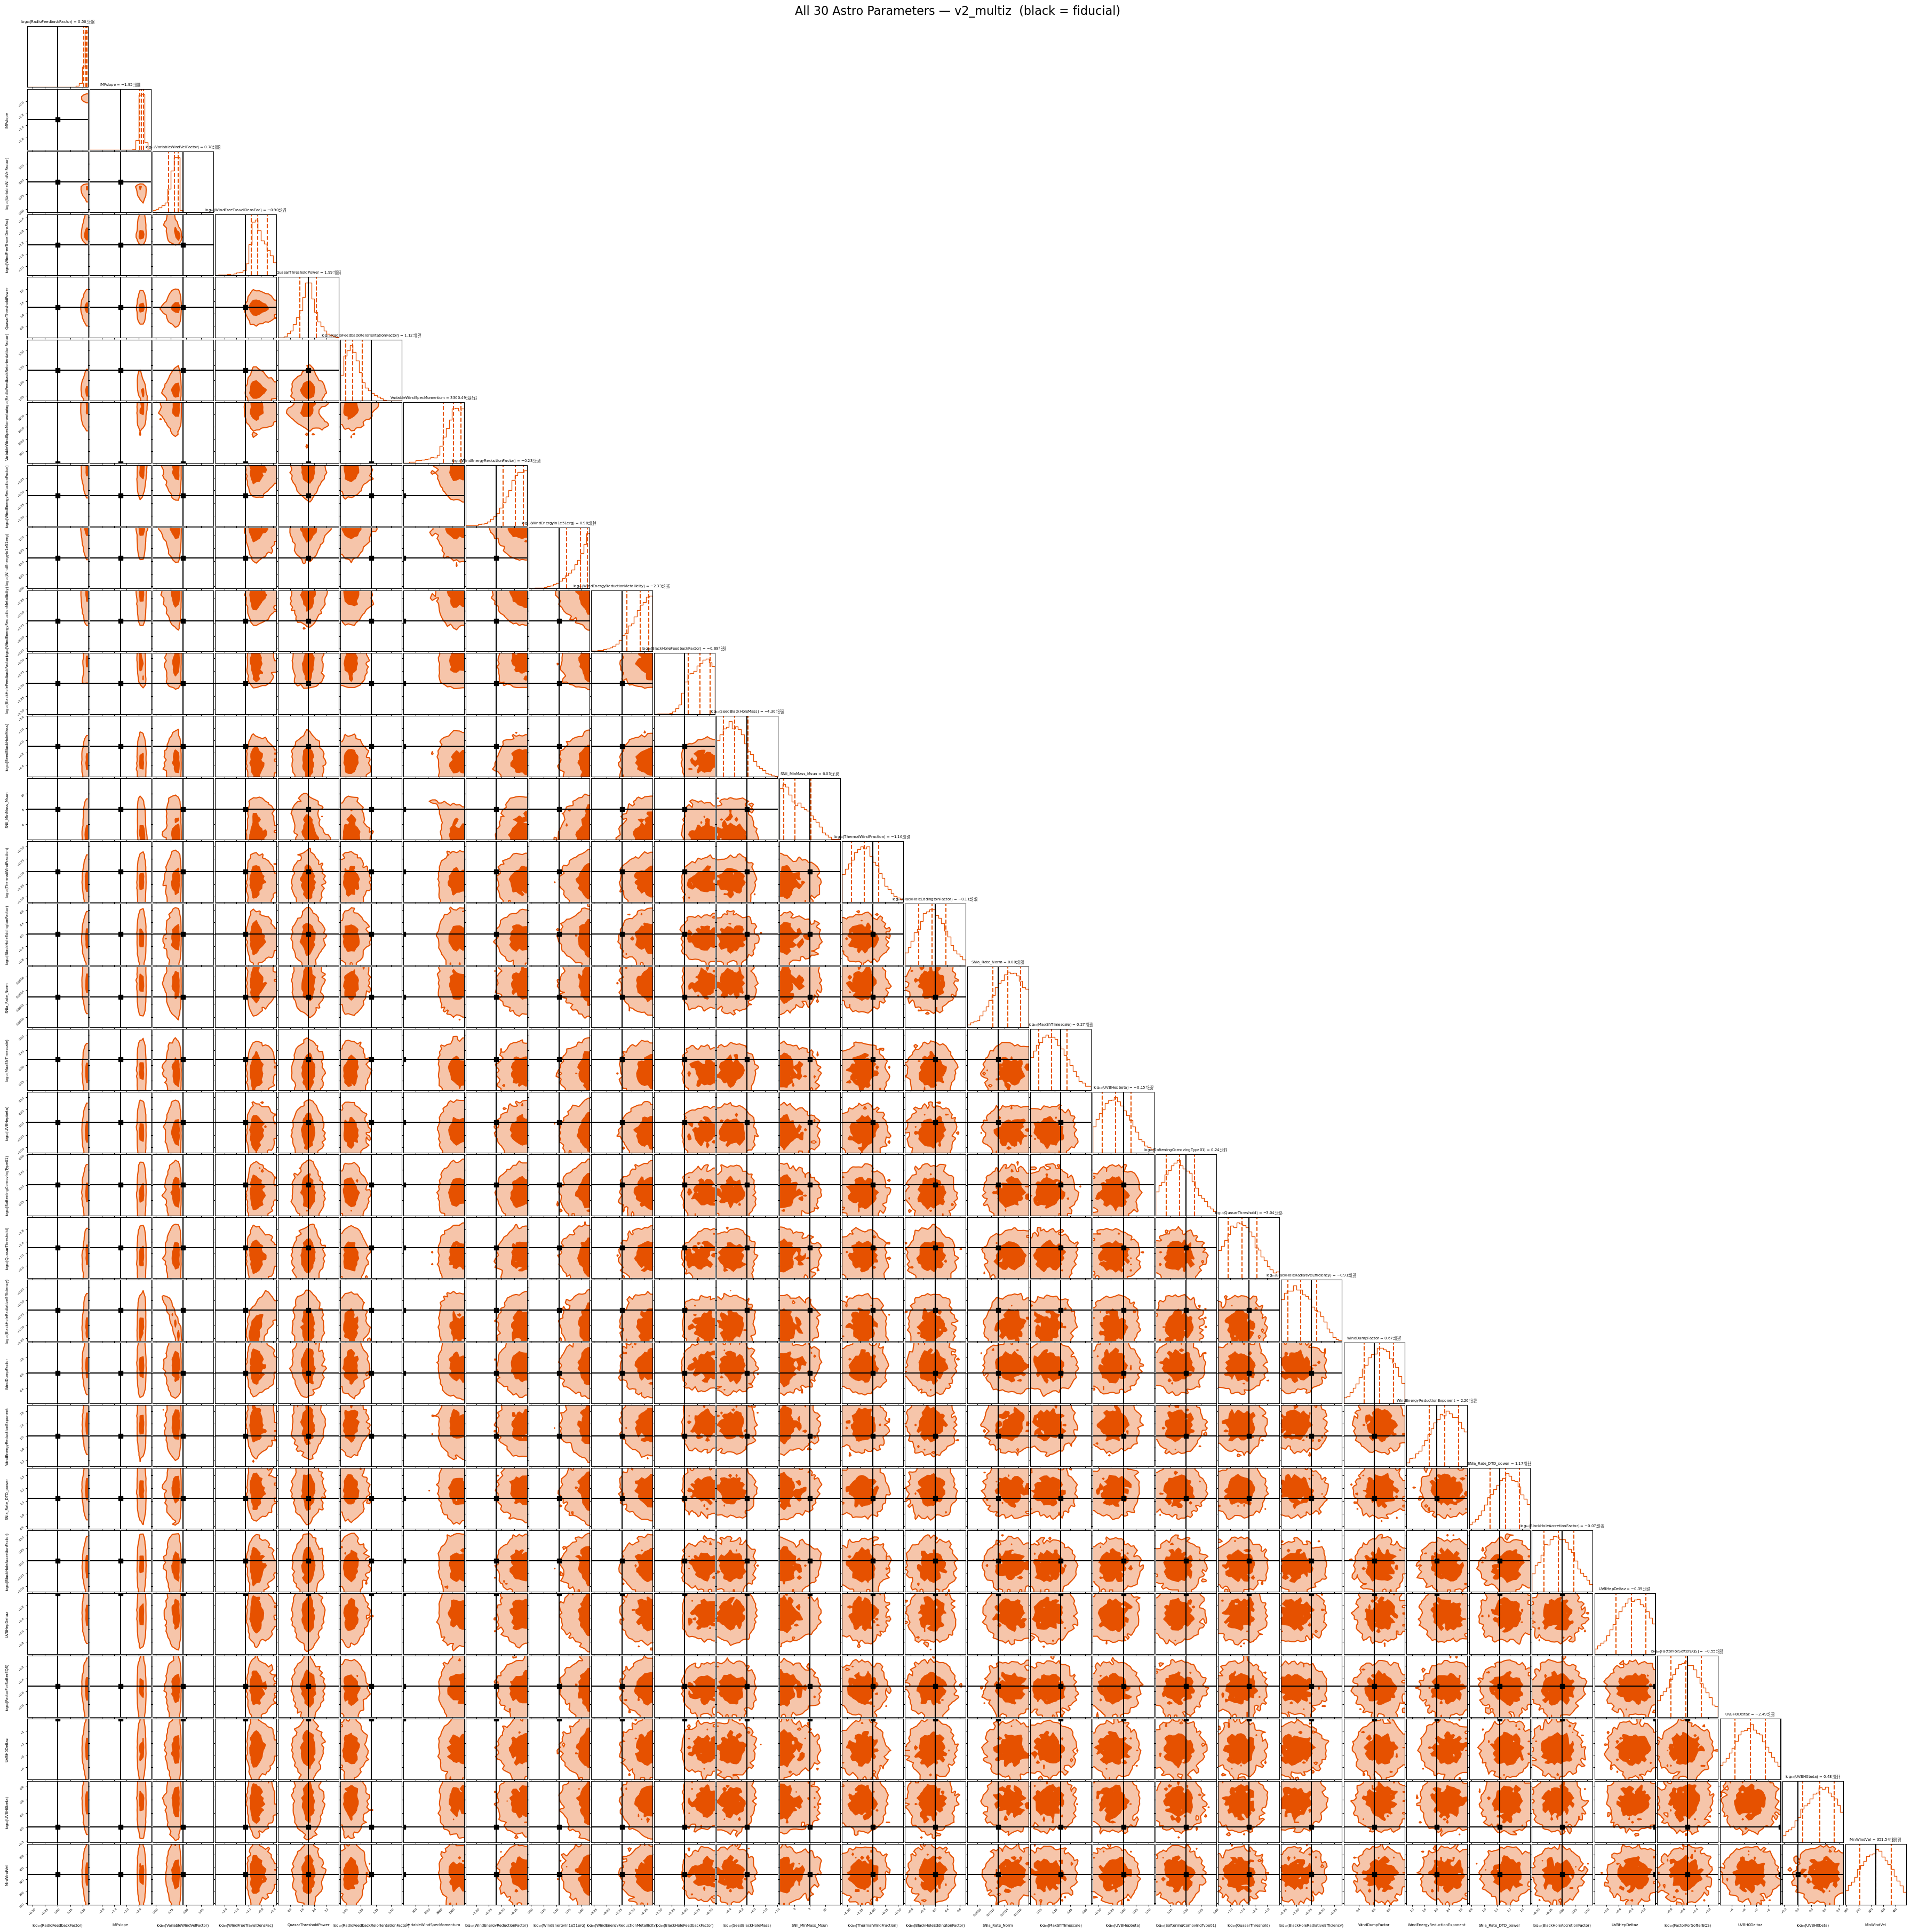

In [24]:
# All astrophysical parameters corner plot (matching v1 style)
try:
    import corner
except ImportError:
    import subprocess; subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'corner'])
    import corner

COSMO_PARAMS = {"Omega0", "sigma8", "OmegaBaryon", "HubbleParam", "n_s"}

# Since FIX_COSMO=True, all selected params are astro; otherwise filter
astro_constraints = [
    (pn, ratios[pn])
    for pn in pipe.selected_param_names
    if pn not in COSMO_PARAMS
]
astro_constraints.sort(key=lambda x: x[1])

print(f"All {len(astro_constraints)} astrophysical parameters (sorted by constraining power):")
for pn, wf in astro_constraints:
    si = list(pipe.selected_param_names).index(pn)
    s_int = pipe.samples_internal[:, si]
    p16, p84 = np.percentile(s_int, [16, 84])
    med = np.median(s_int)
    flag = " ✓" if wf < 0.7 else ""
    print(f"  {pn:35s}: median={med:.4g}, "
          f"68%=[{p16:.4g}, {p84:.4g}], w/prior={wf:.2f}{flag}")

# Corner plot of ALL astro parameters
all_astro_idx = [list(pipe.selected_param_names).index(pn) for pn, _ in astro_constraints]

all_astro_names = []
for i in all_astro_idx:
    pn = pipe.selected_param_names[i]
    if pipe.is_log_param[i]:
        all_astro_names.append(f"log₁₀({pn})")
    else:
        all_astro_names.append(pn)

all_astro_samples = pipe.samples_internal[:, all_astro_idx]
all_astro_ranges = [(pipe.prior_lo[i], pipe.prior_hi[i]) for i in all_astro_idx]

# Fiducial values in internal space (log10 for log-uniform params)
astro_truths = []
for i in all_astro_idx:
    fi = list(pipe.param_names).index(pipe.selected_param_names[i])
    fid_val = float(pipe.fiducial_params[fi])
    if pipe.is_log_param[i]:
        fid_val = np.log10(fid_val)
    astro_truths.append(fid_val)

n_astro = len(all_astro_idx)
fig = corner.corner(
    all_astro_samples,
    labels=all_astro_names,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=astro_truths,
    truth_color="black",
    title_kwargs={"fontsize": 5, "pad": 4},
    label_kwargs={"fontsize": 5, "labelpad": 12},
    range=all_astro_ranges,
    plot_datapoints=False,
    fill_contours=True,
    smooth=0.1,
    levels=(1 - np.exp(-0.5 * np.array([1, 2]) ** 2)),
    color="#E65100",
    fig=plt.figure(figsize=(36, 36)),
)

# Tighten spacing
for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=4, pad=1, length=2)
    if ax.get_xlabel():
        ax.xaxis.labelpad = 10
    if ax.get_ylabel():
        ax.yaxis.labelpad = 10

fig.subplots_adjust(hspace=0.03, wspace=0.03)
fig.suptitle(
    f"All {n_astro} Astro Parameters — {tag}  (black = fiducial)",
    fontsize=16, y=1.005,
)
plt.savefig(f'../sbi_results/corner_astro_{tag}.png', dpi=150, bbox_inches='tight')
plt.show()

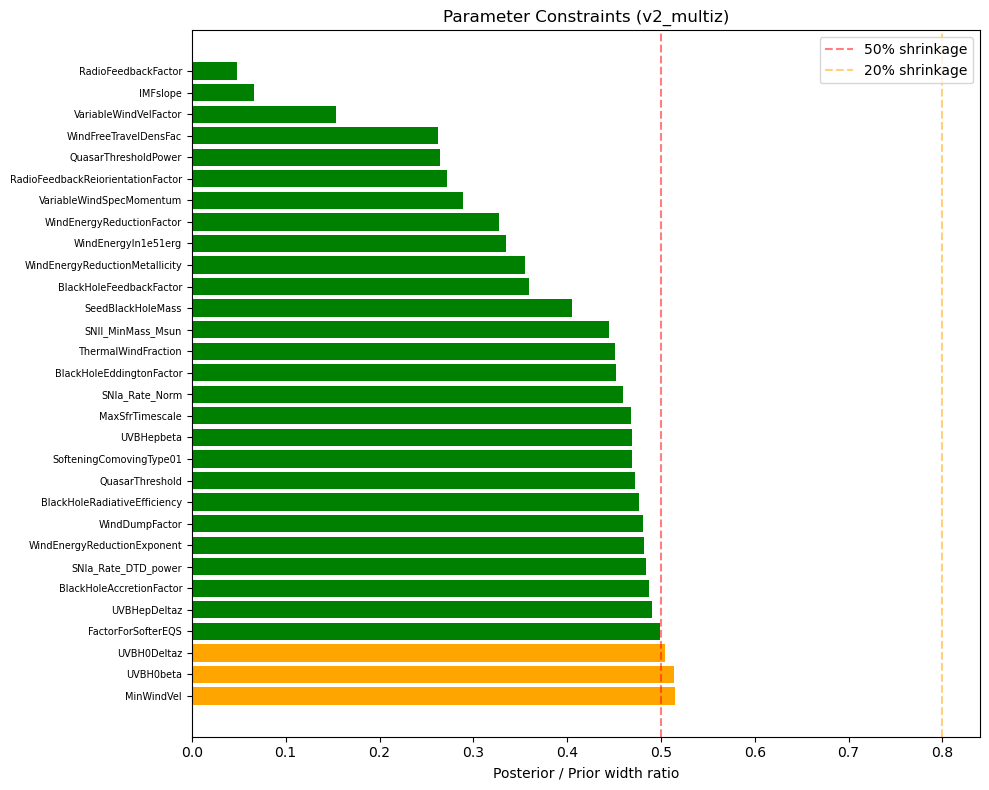

In [20]:
# Constraint improvement summary
fig, ax = plt.subplots(figsize=(10, 8))
all_names = [pn for pn, _ in sorted_params]
all_ratios = [r for _, r in sorted_params]

colors = ['green' if r < 0.5 else 'orange' if r < 0.8 else 'grey'
          for r in all_ratios]
ax.barh(range(len(all_names)), all_ratios, color=colors)
ax.set_yticks(range(len(all_names)))
ax.set_yticklabels(all_names, fontsize=7)
ax.axvline(0.5, color='red', ls='--', alpha=0.5, label='50% shrinkage')
ax.axvline(0.8, color='orange', ls='--', alpha=0.5, label='20% shrinkage')
ax.set_xlabel('Posterior / Prior width ratio')
ax.set_title(f'Parameter Constraints ({tag})')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'../sbi_results/constraints_{tag}.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare v1 vs v2 (optional)

Load v1 constraints and compare constraint widths.

In [ ]:
v1_file = Path('../sbi_results/anp_npe_v1_constraints.json')
if v1_file.exists():
    with open(v1_file) as f:
        v1 = json.load(f)
    
    print(f'{"Parameter":>40s}  v1_ratio  v2_ratio  improvement')
    print('-' * 75)
    for pn in all_names:
        if pn in v1 and pn in constraints:
            r1 = v1[pn]['width_prior_ratio']
            r2 = constraints[pn]['width_prior_ratio']
            imp = (r1 - r2) / r1 * 100 if r1 > 0 else 0
            marker = '***' if imp > 20 else '**' if imp > 10 else '*' if imp > 0 else ''
            print(f'{pn:>40s}  {r1:.3f}     {r2:.3f}     {imp:+.1f}% {marker}')
else:
    print('No v1 constraints found for comparison.')

                               Parameter  v1_ratio  v2_ratio  improvement
---------------------------------------------------------------------------


## Phase 4: Simulation-Based Calibration (SBC)

Run SBC to validate that posterior credible intervals have correct coverage.
This draws test parameters from the prior, generates simulated summaries,
and checks whether the truth falls within the expected credible intervals.

**Note**: SBC is computationally expensive — 200 trials × 1000 posterior samples each.
Set `RUN_SBC = True` to enable.

In [ ]:
RUN_SBC = False  # Set True to run SBC validation (slow!)

if RUN_SBC:
    sbc = pipe.run_sbc(n_sbc_trials=200, n_posterior_per_trial=1000)
    
    # Plot SBC coverage
    import matplotlib.pyplot as plt
    
    levels = sorted(sbc['coverage'].keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # (a) Coverage calibration plot
    ax = axes[0]
    param_names = sbc['param_names']
    n_params = len(param_names)
    for lvl in levels:
        cov = sbc['coverage'][lvl]
        ax.scatter([lvl]*n_params, cov, alpha=0.3, s=20, color='steelblue')
        ax.scatter(lvl, cov.mean(), s=80, color='red', marker='D', zorder=5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='ideal')
    ax.set_xlabel('Nominal credible level')
    ax.set_ylabel('Empirical coverage')
    ax.set_title('SBC Coverage Calibration')
    ax.legend()
    
    # (b) Rank histogram (should be uniform if well-calibrated)
    ax = axes[1]
    ranks = sbc['ranks']
    valid = np.isfinite(ranks[:, 0])
    for pi in range(min(n_params, 5)):
        ax.hist(ranks[valid, pi], bins=20, alpha=0.4, label=param_names[pi])
    ax.axhline(valid.sum()/20, color='k', ls='--', alpha=0.5, label='uniform')
    ax.set_xlabel('Rank (fraction of posterior below truth)')
    ax.set_ylabel('Count')
    ax.set_title('SBC Rank Histograms (first 5 params)')
    ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f'../sbi_results/sbc_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\nSBC Coverage Summary:")
    for lvl in levels:
        mean_cov = sbc['coverage'][lvl].mean()
        print(f"  {int(lvl*100)}% CI: mean coverage = {mean_cov:.1%} (expected {lvl:.0%})")
else:
    print("SBC disabled. Set RUN_SBC = True to run.")

## Phase 4: Multi-dataset Ablation

Remove each survey source one at a time and compare constraint widths.
Identifies which observational datasets contribute most to constraining power.

**Note**: Requires multiple NPE training runs. Set `RUN_ABLATION = True` to enable.

In [ ]:
RUN_ABLATION = False  # Set True to run ablation analysis (slow!)

if RUN_ABLATION:
    ablation = pipe.run_ablation(n_sims=50_000, n_posterior=5_000)
    
    # Plot ablation comparison
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    groups = list(ablation.keys())
    param_names = pipe.selected_param_names
    n_params = len(param_names)
    x = np.arange(n_params)
    width = 0.8 / len(groups)
    
    for gi, group in enumerate(groups):
        constraints = ablation[group].get('constraints', {})
        ratios = [constraints.get(pn, {}).get('width_prior_ratio', 1.0)
                  for pn in param_names]
        label = group
        if 'n_clusters' in ablation[group]:
            label += f" ({ablation[group]['n_clusters']} cl.)"
        ax.barh(x + gi * width, ratios, height=width, label=label, alpha=0.7)
    
    ax.set_yticks(x + width * len(groups) / 2)
    ax.set_yticklabels(param_names, fontsize=7)
    ax.axvline(0.5, color='red', ls='--', alpha=0.5)
    ax.set_xlabel('Posterior / Prior width ratio')
    ax.set_title('Ablation: Impact of removing each survey')
    ax.legend(fontsize=8, loc='lower right')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'../sbi_results/ablation_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Ablation disabled. Set RUN_ABLATION = True to run.")

## Phase 3: Loading Additional Surveys

Once survey data is downloaded (see `download_survey_data.py`), load
additional catalogs and merge into the pipeline:

```python
from anp_emulator.observations import (
    load_erosita_efeds, load_chexmate, load_spt_sz,
    load_act_dr6, build_unified_catalog, SELECTION_FUNCTIONS,
)

# Build unified catalog from all available surveys
cat = build_unified_catalog(
    accept_xcop_npz=OBS_NPZ,
    erosita_efeds_dir='../survey_data/efeds',
    chexmate_dir='../survey_data/chexmate',
    spt_dir='../survey_data/spt',
    act_dir='../survey_data/act',
)
print(f"Unified catalog: {cat.n_clusters} clusters")

# Load into pipeline
pipe.load_observations(obs_npz=OBS_NPZ, additional_catalogs={
    'eFEDS': load_erosita_efeds('../survey_data/efeds'),
    'CHEX-MATE': load_chexmate('../survey_data/chexmate'),
})

# Available selection functions for forward-model correction:
print("Selection functions:", list(SELECTION_FUNCTIONS.keys()))
```